# Actividad 2: Clustering no supervisado

- Alex Rubiño Fernández
- Aprendizaje Automático 2
- 11/05/2026
- UNIR

## Índice

1. [Ejercicio 1: Generación y visualización del dataset](#ejercicio-1-generación-y-visualización-del-dataset)
2. [Ejercicio 2: Modelo k-means](#modelo-k-means)
3. [Ejercicio 3: SVM con kernels no lineales y ajuste de hiperparámetros](#ejercicio-3-svm-con-kernels-no-lineales-y-ajuste-de-hiperparámetros)
4. [Ejercicio 4: Visualización de fronteras de decisión y comparativa de rendimiento](#ejercicio-4-visualización-de-fronteras-de-decisión-y-comparativa-de-rendimiento)
5. [Ejercicio 5: Discusión y comparación de resultados](#ejercicio-5-discusión-y-comparación-de-resultados)

## Ejercicio 1: Generación y visualización del dataset

Generamos un dataset sintético con las siguientes características: dos círculos concéntricos con grosor aleatorio, tres círculos adicionales también con grosor aleatorio (algunos de ellos se cortan entre sí y con los círculos concéntricos), y seis bloques compactos distribuidos entre los círculos anteriores. Por último, visualizamos el dataset resultante.

Para ello, creamos una función generar_circulo que genera puntos alrededor de un círculo con ruido gaussiano para simular el grosor. Generamos dos círculos concéntricos centrados en (0,0) con radios 1.0 y 1.8 respectivamente, ambos con 400 puntos y un grosor de 0.08. A continuación, generamos tres círculos adicionales: el círculo 3 centrado en (2.2, 1.2) con radio 0.9, el círculo 4 en (1.8, -1.5) con radio 0.8, y el círculo 5 en (-2.0, 1.3) con radio 0.8, todos ellos con grosor 0.07 y 300 puntos cada uno. Para los seis bloques compactos, utilizamos make_blobs generando 60 muestras alrededor de cada centro, con una desviación estándar de 0.08. Los centros de los bloques son: (0.6, 1.3), (-0.7, 1.4), (1.3, -0.6), (-1.2, -0.7), (1.4, 0.7) y (-1.4, 0.9). Finalmente, combinamos todos los puntos en un único dataset sin etiquetas (aprendizaje no supervisado) y mostramos los datos en un gráfico de dispersión.

Círculo interior (radio 1.2): 650 puntos
Círculo exterior (radio 2.5): 800 puntos

Círculo adicional 1 (centro 0.5,0.3 radio 0.5): 400 puntos
Círculo adicional 2 (centro -0.4,0.6 radio 0.45): 400 puntos
Círculo adicional 3 (centro 0.1,-0.7 radio 0.5): 400 puntos
Bloque 1: 60 puntos en (-0.3, -0.1)
Bloque 2: 60 puntos en (0.55, 0.35)
Bloque 3: 60 puntos en (1.3, -0.6)
Bloque 4: 60 puntos en (-1.2, -0.7)
Bloque 5: 60 puntos en (1.4, 0.7)
Bloque 6: 60 puntos en (-1.4, 0.9)

Total puntos en bloques compactos: 360
Dataset final: 3010 muestras, 2 características
NOTA: No se incluyen etiquetas (aprendizaje no supervisado)


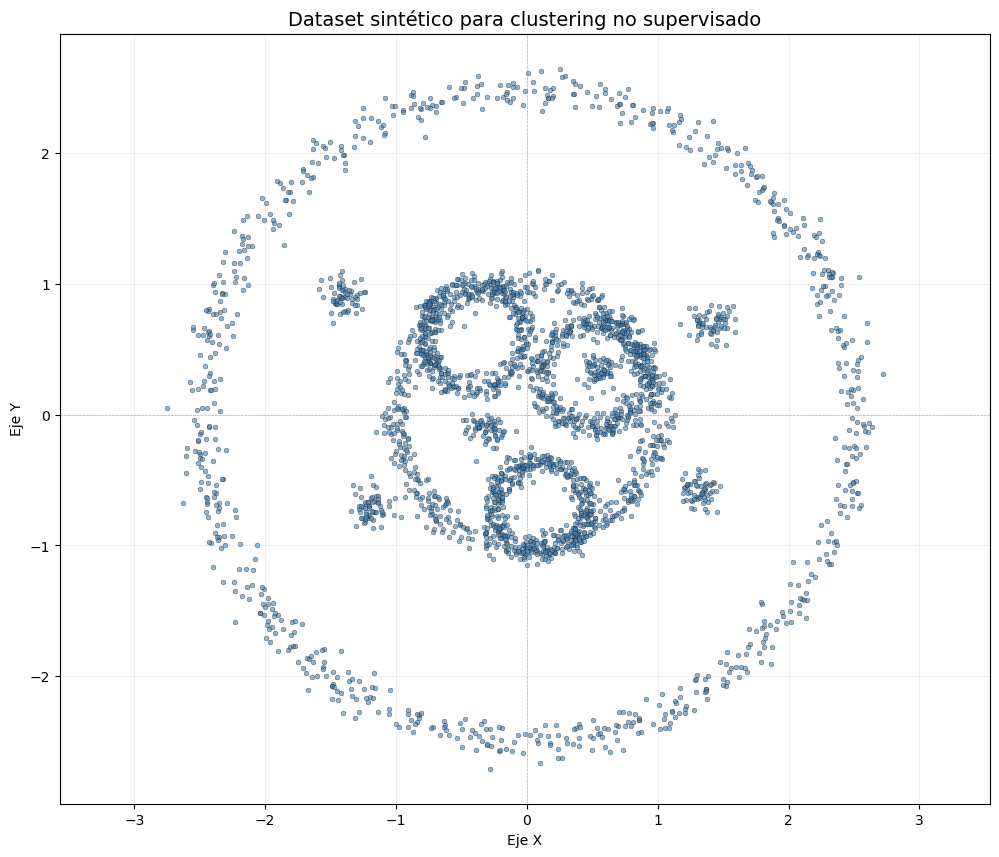

In [44]:
# Importamos las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Fijamos semilla para reproducibilidad
np.random.seed(42)

def generar_circulo(centro_x, centro_y, radio, n_puntos, grosor):
    """
    Genera puntos alrededor de un círculo con grosor (ruido gaussiano)
    """
    angulos = np.random.uniform(0, 2*np.pi, n_puntos)
    r = radio + np.random.normal(0, grosor, n_puntos)
    x = centro_x + r * np.cos(angulos)
    y = centro_y + r * np.sin(angulos)
    return np.column_stack([x, y])

# Dos círculos concéntricos en (0,0)
circulo_int = generar_circulo(0, 0, 1, 650, 0.06)   # círculo interior
circulo_ext = generar_circulo(0, 0, 2.5, 800, 0.08)   # círculo exterior

print(f"Círculo interior (radio 1.2): {circulo_int.shape[0]} puntos")
print(f"Círculo exterior (radio 2.5): {circulo_ext.shape[0]} puntos")

# Círculo 1: centrado en (0.5, 0.3) con radio 0.40
circulo_adicional1 = generar_circulo(0.5, 0.3, 0.4, 400, 0.05)

# Círculo 2: centrado en (-0.4, 0.6) con radio 0.40
circulo_adicional2 = generar_circulo(-0.4, 0.6, 0.4, 400, 0.05)

# Círculo 3: centrado en (0.1, -0.7) con radio 0.35 (se corta con los anteriores)
circulo_adicional3 = generar_circulo(0.1, -0.7, 0.35, 400, 0.05)

print(f"\nCírculo adicional 1 (centro 0.5,0.3 radio 0.5): {circulo_adicional1.shape[0]} puntos")
print(f"Círculo adicional 2 (centro -0.4,0.6 radio 0.45): {circulo_adicional2.shape[0]} puntos")
print(f"Círculo adicional 3 (centro 0.1,-0.7 radio 0.5): {circulo_adicional3.shape[0]} puntos")

# Posiciones de los 6 bloques compactos
centros_blobs = [
    (-0.3, -0.1), (0.55, 0.35), (1.3, -0.6),
    (-1.2, -0.7), (1.4, 0.7), (-1.4, 0.9)
]

bloques = []
for i, centro in enumerate(centros_blobs):
    blob, _ = make_blobs(n_samples=60, centers=[centro], cluster_std=0.08, n_features=2)
    bloques.append(blob)
    print(f"Bloque {i+1}: {blob.shape[0]} puntos en {centro}")

# Unir todos los bloques en un solo array
bloques_compactos = np.vstack(bloques)
print(f"\nTotal puntos en bloques compactos: {bloques_compactos.shape[0]}")
# Unir todos los componentes
X = np.vstack([circulo_int, circulo_ext, circulo_adicional1, circulo_adicional2, circulo_adicional3, bloques_compactos])

print(f"Dataset final: {X.shape[0]} muestras, {X.shape[1]} características")
print("NOTA: No se incluyen etiquetas (aprendizaje no supervisado)")

plt.figure(figsize=(12, 10))

plt.scatter(X[:, 0], X[:, 1], s=12, alpha=0.6, c='steelblue', edgecolors='k', linewidth=0.3)

plt.title('Dataset sintético para clustering no supervisado', fontsize=14)
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.axis('equal')
plt.grid(alpha=0.2)
plt.show()

## Ejercicio 2: Modelo k-means

Entrenamos un modelo de k-means sobre el dataset generado. Primero estandarizamos los datos, ya que k-means es sensible a la escala de las características. A continuación, determinamos el número óptimo de clústeres utilizando el método del codo (inercia) y el coeficiente de silhouette. Finalmente, entrenamos el modelo con el número óptimo de clústeres y visualizamos los resultados.

El algoritmo k-means calcula distancias euclidianas entre los puntos para asignarlos a clústeres. Si las características están en diferentes escalas, aquellas con valores numéricamente más grandes dominarían el cálculo de la distancia, sesgando el resultado. Por ello, aplicamos `StandardScaler()` para transformar los datos de manera que tengan media 0 y desviación estándar 1. Esto asegura que todas las características contribuyan por igual al clustering.

In [58]:
# Ejercicio 2: k-means clustering

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Estandarizamos los datos mediante StandardScaler()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

A diferencia de la clasificación supervisada, en clustering no disponemos de etiquetas para evaluar el modelo. Por tanto, debemos utilizar métricas internas para seleccionar el hiperparámetro k. Utilizamos dos métodos complementarios:

1. **Método del codo (inercia):** La inercia mide la suma de las distancias al cuadrado de cada punto respecto a su centroide. Al aumentar k, la inercia disminuye porque los puntos están más cerca de sus respectivos centroides. El punto de inflexión (codo) indica el valor de k a partir del cual la mejora es marginal y sugiere un número adecuado de clústeres.

2. **Coeficiente de silhouette:** Mide lo similares que son los puntos dentro de un mismo clúster frente a puntos de otros clústeres. Su valor oscila entre -1 y 1, donde valores cercanos a 1 indican que los puntos están bien agrupados y separados de otros clústeres. Seleccionamos el k que maximiza este coeficiente.

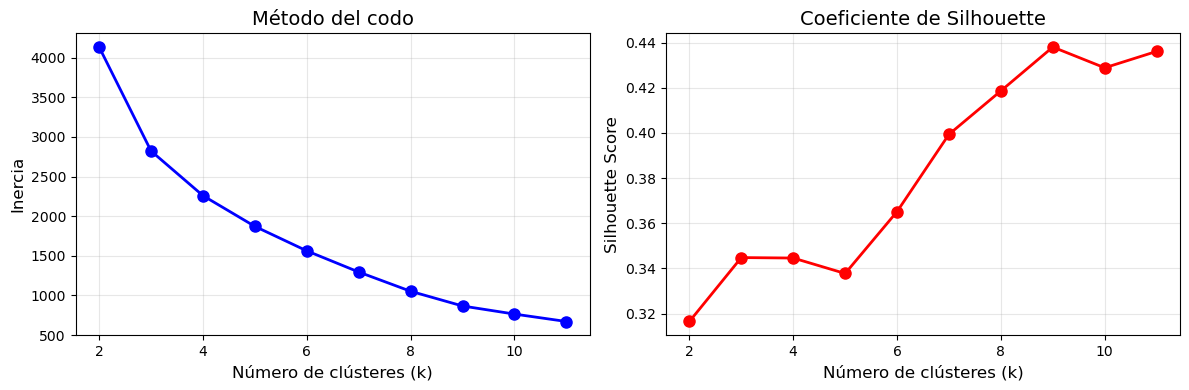

Mejor número de clústeres según silhouette score: 9
Silhouette score para k=9: 0.4380


In [62]:
# Determinar el número óptimo de clústeres
inertias = []
silhouette_scores = []
K_range = range(2, 12)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Visualizar el método del codo y silhouette
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertias, 'bo-', markersize=8, linewidth=2)
axes[0].set_xlabel('Número de clústeres (k)', fontsize=12)
axes[0].set_ylabel('Inercia', fontsize=12)
axes[0].set_title('Método del codo', fontsize=14)
axes[0].grid(alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', markersize=8, linewidth=2)
axes[1].set_xlabel('Número de clústeres (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Coeficiente de Silhouette', fontsize=14)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Mostrar el mejor k según silhouette
best_k = K_range[np.argmax(silhouette_scores)]
print(f"Mejor número de clústeres según silhouette score: {best_k}")
print(f"Silhouette score para k={best_k}: {max(silhouette_scores):.4f}")

En las gráficas obtenidas observamos que, en el método del codo, la inercia disminuye rápidamente hasta k=5 y luego se produce un cambio de pendiente. A partir de k=6, la reducción de la inercia es más gradual, lo que sugiere que añadir más clústeres no mejora significativamente la compactación de los grupos. En el coeficiente de silhouette, el valor máximo se alcanza con k=9, con un score de 0.4380. Aunque no es un valor excelente, es el mejor dentro del rango evaluado.

La estructura geométrica del dataset dificulta que k-means, que asume clústeres esféricos y de igual tamaño, encuentre una partición óptima. El método del codo sugiere un valor de k entre 4 y 5, mientras que el silhouette score indica que k=9 es mejor desde el punto de vista de separación entre clústeres. Entrenaremos k-means con **k=9** y evaluaremos visualmente los resultados.

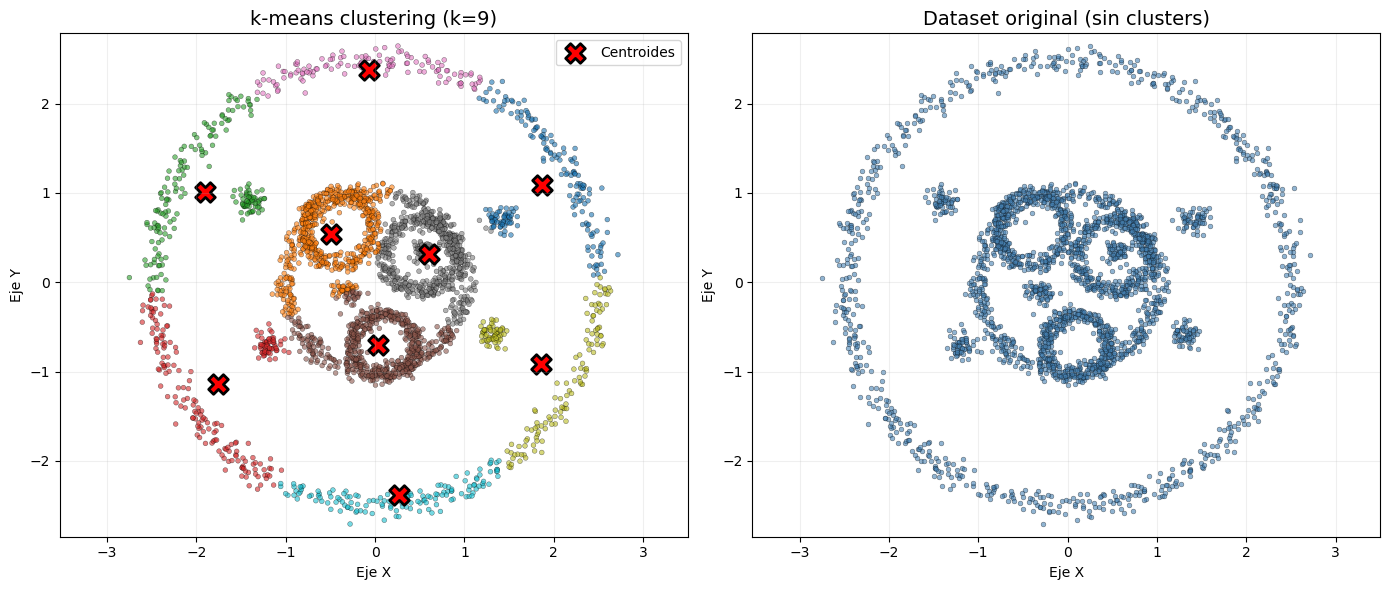

Estadísticas del modelo k-means:
  - Número de clústeres: 9
  - Inercia: 867.41
  - Número de iteraciones: 11
  - Silhouette score: 0.4380


In [65]:
# Entrenar k-means con el número óptimo de clústeres
kmeans_optimal = KMeans(n_clusters=best_k, random_state=42, n_init=10)
y_kmeans = kmeans_optimal.fit_predict(X_scaled)

# Visualizar los resultados de k-means
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico con los clusters coloreados
scatter = axes[0].scatter(X[:, 0], X[:, 1], c=y_kmeans, s=12, alpha=0.6, cmap='tab10', edgecolors='k', linewidth=0.3)

# Centroides
centroids = scaler.inverse_transform(kmeans_optimal.cluster_centers_)
axes[0].scatter(centroids[:, 0], centroids[:, 1], s=200, c='red', marker='X', edgecolors='black', linewidth=2, label='Centroides')
axes[0].set_title(f'k-means clustering (k={best_k})', fontsize=14)
axes[0].set_xlabel('Eje X')
axes[0].set_ylabel('Eje Y')
axes[0].legend()
axes[0].axis('equal')
axes[0].grid(alpha=0.2)

# Dataset original para comparación
axes[1].scatter(X[:, 0], X[:, 1], s=12, alpha=0.6, c='steelblue', edgecolors='k', linewidth=0.3)
axes[1].set_title('Dataset original (sin clusters)', fontsize=14)
axes[1].set_xlabel('Eje X')
axes[1].set_ylabel('Eje Y')
axes[1].axis('equal')
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

# Estadísticas adicionales de k-means
print("Estadísticas del modelo k-means:")
print(f"  - Número de clústeres: {best_k}")
print(f"  - Inercia: {kmeans_optimal.inertia_:.2f}")
print(f"  - Número de iteraciones: {kmeans_optimal.n_iter_}")
print(f"  - Silhouette score: {silhouette_score(X_scaled, y_kmeans):.4f}")

Entrenando el modelo con k=9, obtenemos que en el gráfico de la izquierda se observan los 9 clústeres identificados por k-means, representados con diferentes colores. Los centroides se muestran como grandes aspas rojas. En el gráfico de la derecha se muestra el dataset original sin etiquetar para comparación.

k-means consigue agrupar parte de la estructura del dataset, pero presenta limitaciones. Los clústeres tienden a ser esféricos y de tamaño similar, lo que no se ajusta bien a la forma de los círculos concéntricos ni a los círculos adicionales que se cortan. Algunos bloques compactos quedan bien identificados, mientras que otros se mezclan con puntos de los círculos.

El modelo converge después de 11 iteraciones, con una inercia de 867.41. El silhouette score obtenido es de 0.4380, el mismo que calculamos durante la selección de k. Este valor moderado confirma que, aunque hay cierta estructura, los clústeres no están perfectamente definidos debido a la geometría compleja del dataset y a las limitaciones de k-means para detectar formas no convexas.

## Ejercicio 3: Modelo DBSCAN

Entrenamos un modelo DBSCAN sobre el dataset generado. DBSCAN es un algoritmo basado en densidad que no requiere especificar el número de clústeres a priori, a diferencia de k-means. Esto lo hace adecuado para datasets con formas no convexas y densidades variables, como es nuestro caso.

DBSCAN tiene dos hiperparámetros principales:

- **eps:** distancia máxima entre dos puntos para que sean considerados vecinos.
- **min_samples:** número mínimo de puntos necesarios para formar una región densa (clúster).

Para determinar eps, utilizamos el gráfico de distancias al k-ésimo vecino. Seleccionamos k = min_samples, que típicamente se establece como 2 * número de dimensiones (en nuestro caso, 2D, por lo tanto min_samples = 4). El gráfico muestra las distancias ordenadas de cada punto a su cuarto vecino más cercano. Buscamos el punto de inflexión (codo) donde la distancia empieza a aumentar bruscamente.